In [44]:
import xarray as xr
import matplotlib.pyplot as plt 
import seaborn as sns
import cartopy.crs as ccrs
import seaborn.objects as so
import numpy as np
from dask.distributed import LocalCluster, Client
import flox.xarray
import xesmf as xe
from affine import Affine

from tqdm.notebook import tqdm
import scipy
import dask.bag as db
from pyproj import Proj, Transformer, CRS
import geopandas as gpd
from rasterio import features
from shapely.geometry import shape

import pandas as pd
plt.style.use('robin')
proj = ccrs.NorthPolarStereo(0,70)

In [2]:
cluster = LocalCluster(n_workers=8, memory_limit='12GiB')
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 64,Total memory: 96.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41769,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39019,Total threads: 8
Dashboard: http://127.0.0.1:42891/status,Memory: 12.00 GiB
Nanny: tcp://127.0.0.1:38523,


# Load experiments results

In [3]:
# run_id = '3w874ud3'
# run_id = '0obl1joe'
run_id = '75kakckt'
# ds_attrs = xr.open_dataset(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_attributions.nc', chunks = dict(time_of_event=20)).load()
ds_attrs = xr.open_dataset(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_ALL_attributions_v2.nc', chunks = dict(time_of_event=20)).load().transpose('y','x',...)

grid = ds_attrs.isel(time_of_event=0, timestep_past=0, var_name=0).features
lrp_normed = ds_attrs.attributions_lrp 
lrp_normed = lrp_normed.sum('var_name')/lrp_normed.sum('var_name').clip(0).sum(['x','y'])
ds_attrs['lrp_normed'] = lrp_normed
ig_normed = ds_attrs.attributions_ig 
ig_normed = ig_normed/ig_normed.sum('var_name').max(['x','y'])
# cycs = cycs.query("msl<100000")
ds_attrs

<xarray.Dataset> Size: 6GB
Dimensions:           (time_of_event: 937, y: 128, x: 128, timestep_past: 7,
                       var_name: 4)
Coordinates:
    quantile          float64 8B 0.95
  * y                 (y) float64 1kB -1e+07 -9.882e+06 ... 4.824e+06 4.941e+06
  * x                 (x) float64 1kB -1e+07 -9.882e+06 ... 4.824e+06 4.941e+06
  * var_name          (var_name) <U4 64B 'u850' 'v850' 'msl' 'z500'
    lat               (y, x) float32 66kB -7.882 -7.546 -7.21 ... 31.67 31.09
    lon               (y, x) float32 66kB -45.0 -44.66 -44.32 ... 135.7 135.0
  * timestep_past     (timestep_past) int64 56B -6 -5 -4 -3 -2 -1 0
  * time_of_event     (time_of_event) datetime64[ns] 7kB 1979-01-07 ... 2025-...
Data variables:
    rain              (time_of_event) float64 7kB 30.89 37.58 ... 23.69 27.42
    targets           (time_of_event) float64 7kB 1.0 1.0 1.0 ... 1.0 1.0 1.0
    features          (y, x, time_of_event, timestep_past, var_name) float32 2GB ...
    attributions_lrp  (y, x, time_of_event, timestep_past, var_name) float32 2GB ...
    predictions       (time_of_event, timestep_past) float32 26kB -0.5857 ......
    attributions_ig   (y, x, time_of_event, timestep_past, var_name) float32 2GB ...
    lrp_normed        (y, x, time_of_event, timestep_past) float32 430MB 0.0 ...

# Load cyclone data

In [6]:
all_df_dailys = []
import glob
files = glob.glob('/Data/gfi/share/Reanalyses/ERA-5/detected_features/cyclone_tracks_melbourne/*.pos.nc')
files = [f for f in files if f.endswith('.nc')]
for file in tqdm(files):
    with xr.open_dataset(file) as ds:
        df_ = ds[['track_id', 'lon','lat','msl','date']].to_dataframe()
        df_['date'] = pd.to_datetime(df_.date.dt.date)
        df_daily = df_.groupby(['date','track_id']).agg({'msl':'min','lon':'mean','lat':'mean'}).reset_index()   
        all_df_dailys.append(df_daily)
        del df_
daily_cycs = pd.concat(all_df_dailys)
proj_stereo = CRS(f"+proj=stere +lat_0=90 +lat_ts=70 +lon_0=0 +x_0=0 +y_0=0 +ellps=WGS84 +units=m")
transformer = Transformer.from_crs("EPSG:4326", proj_stereo, always_xy=True)
# x,y = lonlat_to_northpolarstereo(cycs['lon'].values, cycs['lat'].values, central_longitude=0, latitude_of_true_scale=70)
x,y = transformer.transform(daily_cycs['lon'].values, daily_cycs['lat'].values)
daily_cycs['x'] = x
daily_cycs['y'] = y
daily_cycs = daily_cycs.loc[(daily_cycs.x > -1e7)&(daily_cycs.x < 5e6)&(daily_cycs.y > -1e7)&(daily_cycs.y < 5e6)]

time_min = pd.to_datetime(ds_attrs.time_of_event.min().values - pd.Timedelta('7D'))
time_max = pd.to_datetime(ds_attrs.time_of_event.max().values)

daily_cycs = daily_cycs.loc[(daily_cycs.date>=time_min) & (daily_cycs.date<=time_max)]
daily_cycs = daily_cycs.set_index('date').sort_index()
daily_cycs['track_id']=daily_cycs['track_id'].astype(int).astype(float)


cyclones_gdf = gpd.GeoDataFrame(
    daily_cycs.reset_index(),
    geometry=gpd.points_from_xy(daily_cycs["x"], daily_cycs["y"]),
    crs=proj  # adjust if your cyclones are in another CRS
).set_index('date')

  0%|          | 0/552 [00:00<?, ?it/s]

In [ ]:

segments_fz = felzenszwalb(np.abs(img), scale=500, sigma=.3, min_size=30)

segments_fz, num_features = scipy.ndimage.label(data.fillna(0).where(np.abs(data)>0.001,0), structure=[[1,1,1],[1,1,1],[1,1,1],])

segments = xr.DataArray(segments_fz, dims=data.dims, coords=data.coords)
fig, ax = plt.subplots()
# segments.where(segments>0).plot(alpha=.3, add_colorbar=False,)
ax.pcolormesh(data.x, data.y,data, cmap='icefire',vmin=-0.003, vmax=0.003, zorder=10, alpha=1)
ax.pcolormesh(data.x, data.y,mark_boundaries(np.ones_like(np.abs(img)), segments_fz, color=0,), alpha=.4, zorder=100,)
sns.scatterplot(daily_cycs.loc['2016-08-06'], x='x', y='y', ax=ax, zorder=100, color='C3', edgecolor='0', size='msl', sizes=(100,10))

plt.figure()
data.groupby(segments).sum().to_series().rename('attributions').plot.barh()


# Cyclones stuff

In [120]:
data = ds_attrs.sel(time_of_event='2016-08-09').sel(timestep_past=-3).lrp_normed
img = data.rolling(x=3,y=3,center=True).mean().fillna(0).values
img = img/img.max()

def segments_from_attribution_grid(data, abs_threshold = 0.001, rolling=3):
    data_rolling = data.rolling(x=rolling,y=rolling,center=True).mean().fillna(0)
    data_rolling = data_rolling.where(np.abs(data_rolling)>abs_threshold,0)
    img = data_rolling.values
    img = img/img.max()
    segments_fz, num_features = scipy.ndimage.label(img, structure=[[1,1,1],[1,1,1],[1,1,1],])
    segments = xr.DataArray(segments_fz, dims=data.dims, coords=data.coords)
    attribution_per_segment = data.groupby(segments).sum().to_series().rename('attributions')
    return segments, attribution_per_segment

def get_gdf_from_segment_grid(segments):
    x = segments.x.values
    y = segments.y.values
    labels = segments.values
    dx = float(np.mean(np.diff(x))) 
    dy = float(np.mean(np.diff(y))) 
    x0 = x.min() - dx / 2.0
    y0 = y.min() - dy / 2.0  
    transform = Affine.translation(x0, y0) * Affine.scale(dx, dy)
    geoms = []
    vals = []
    for geom, value in features.shapes(labels, transform=transform):
        if value == 0:
            continue
        geoms.append(shape(geom))
        vals.append(value)
    gdf_segments = gpd.GeoDataFrame(
        {"label": vals},
        geometry=geoms,
        crs="EPSG:3413"   # or "EPSG:3995" or your custom proj string
    )
    return gdf_segments

def get_segments_gdf_for_day(time_of_event, timestep_past, segments_kwargs=dict()):
    data = ds_attrs.sel(time_of_event=time_of_event,timestep_past=timestep_past).lrp_normed
    segments, attribution_per_segment = segments_from_attribution_grid(data, **segments_kwargs)
    gdf_segments = get_gdf_from_segment_grid(segments)
    gdf_segments['attributions'] = attribution_per_segment
    return segments, gdf_segments, attribution_per_segment

def get_cyclones_for_day(time_of_event, timestep_past):
    time = pd.to_datetime(time_of_event) + pd.Timedelta(f'{timestep_past}D')
    print(time)
    cyclones_gdf_day = cyclones_gdf.loc[time.strftime("%Y-%m-%d")]
    return cyclones_gdf_day.set_index('track_id')

def get_intersection(gdf_segments, cyclones_gdf_day):
    intersects = cyclones_day.geometry.apply(lambda g: gdf_segments.intersection(g)).stack()
    
    return gdf_merged

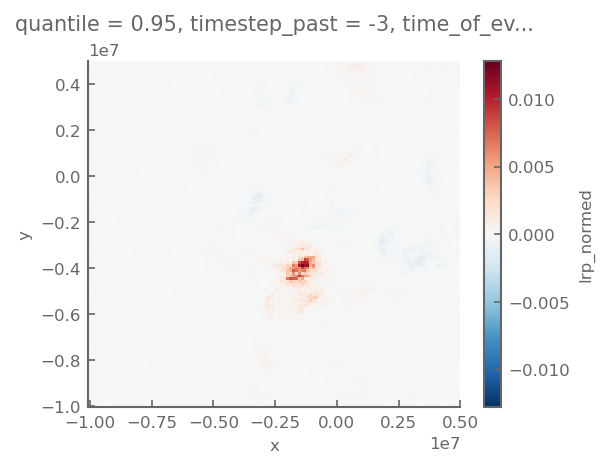

In [129]:
data.clip(0).sum(['x','y'])

data.plot()

In [126]:
segments, gdf_segments, segments = get_segments_gdf_for_day('2016-08-09', -3, segments_kwargs=dict(abs_threshold = 0.001, rolling=3))
gdf_segments.attributions.sum()

np.float32(0.46169367)

/tmp/ipykernel_3174503/4018499826.py:51: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:3413
Right CRS: +proj=stere +ellps=WGS84 +lat_0=90 +lon_0=0 +x_0=0 ...

  gdf_merged = gpd.sjoin(gdf_segments, cyclones_gdf_day, how='inner', predicate='intersects')


<Axes: >

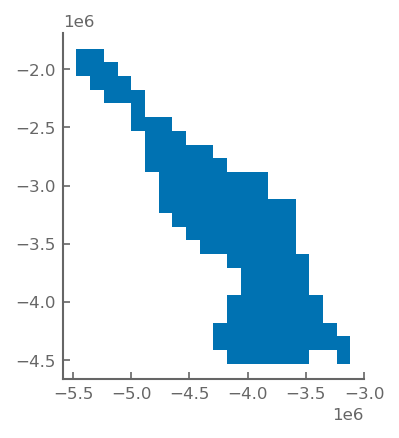

In [ ]:

cyclones_day.geometry.apply(lambda g: gdf_segments.intersection(g)).stack()


2016-08-06 00:00:00


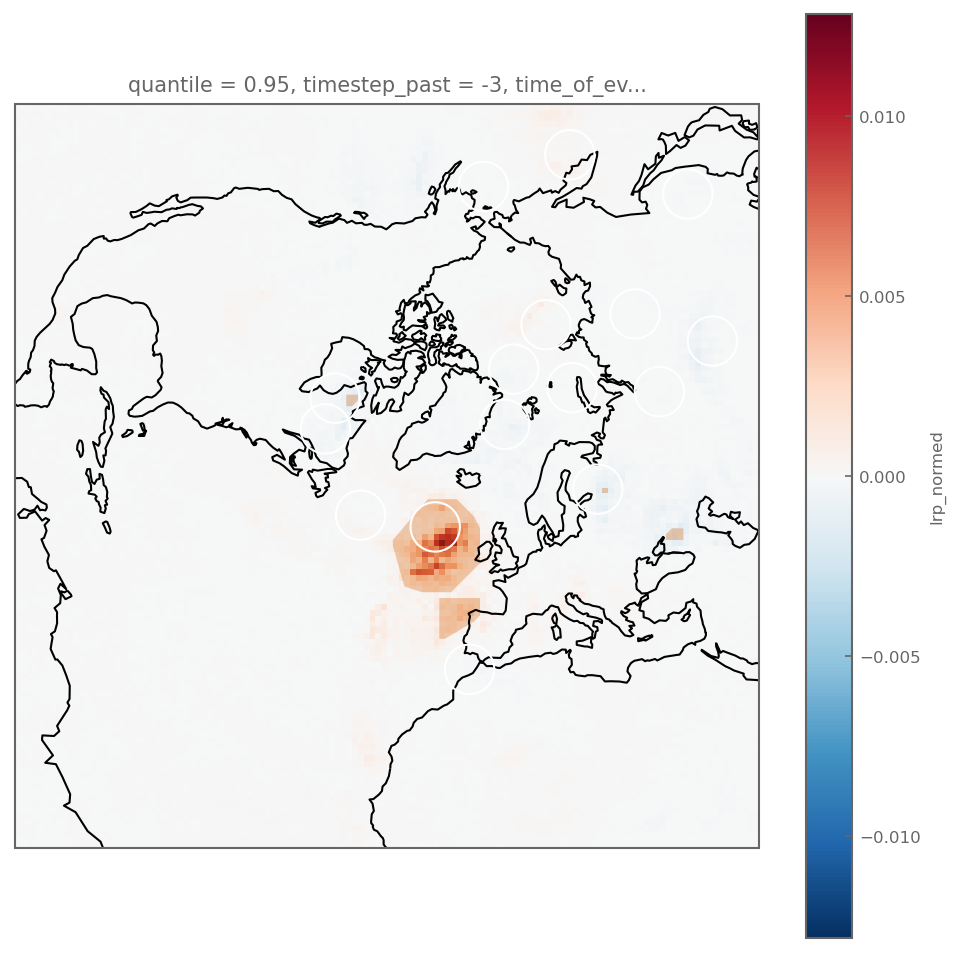

In [113]:
segments, gdf_segments = get_segments_gdf_for_day('2016-08-09', -3, segments_kwargs=dict(abs_threshold = 0.001, rolling=3))
cyclones_day = get_cyclones_for_day('2016-08-09', -3)
data = ds_attrs.sel(time_of_event='2016-08-09').sel(timestep_past=-3).lrp_normed

fig, ax = plt.subplots(figsize=(8,8), subplot_kw={'projection':proj})
data.plot(ax=ax, transform=proj)
gdf_segments.convex_hull.plot( ax=ax, transform=proj, alpha=.3, color='C3')
cyclones_day.geometry.buffer(500_000).plot(ax=ax, zorder=100, color='none', edgecolor='1')


# cyclones_gdf_day.geometry.plot(ax=ax, transform=proj, color='C1', markersize=50)
ax.coastlines()

<Axes: >

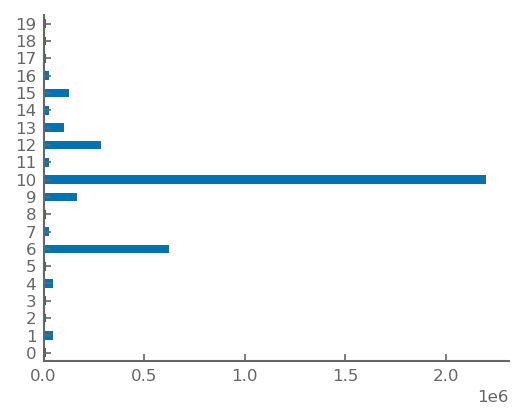

In [57]:
(gdf_segments.convex_hull.area/1_000_000).plot.barh()

<Axes: >

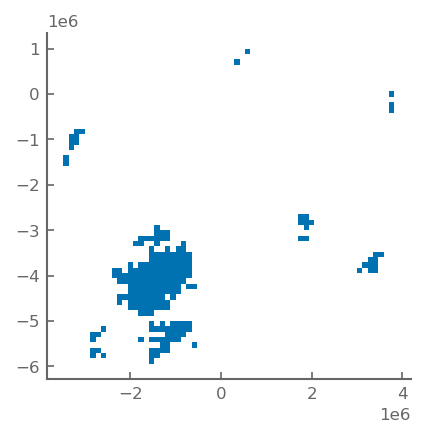

In [47]:
gdf.plot()